# Optimisation de portefeuille — Modèle de Markowitz

**Univers** : S&P 500 — **Période** : 2025 — **Fréquence** : rendements hebdomadaires

---

## Objectif du notebook

Ce notebook implémente le modèle de Markowitz (Modern Portfolio Theory) sur un sous-ensemble du S&P 500, en utilisant **deux méthodes d'optimisation distinctes** (autres que la descente de gradient) :

1. **Méthode analytique par multiplicateurs de Lagrange** — solution en forme fermée pour le problème sans contraintes d'inégalité.
2. **Programmation Quadratique (QP) via CVXPY** — solveur d'optimisation convexe permettant des contraintes réalistes (long-only, plafonds par actif).

Ce sont deux approches **fondamentalement différentes du gradient** :
- Le Lagrangien donne une solution *exacte en un calcul* (pas d'itérations).
- Le QP résout exactement le problème via des méthodes de points intérieurs, sans descente.

## Périmètre

Ce notebook se concentre sur **le modèle pur** : recueil des données, estimation des paramètres, résolution du problème d'optimisation, tracé de la frontière efficiente. 

## Plan

1. Imports et configuration
2. Recueil des données (yfinance)
3. Calcul des rendements hebdomadaires
4. Estimation de μ et Σ
5. **Méthode 1** — Optimisation par Lagrangien analytique
6. **Méthode 2** — Optimisation par programmation quadratique (CVXPY)
7. Comparaison des deux méthodes
8. Conclusion et prochaines étapes

## 1. Imports et configuration

On utilise :

- `numpy`, `pandas` pour la manipulation des données et l'algèbre linéaire ;
- `yfinance` pour récupérer les prix historiques ;
- `matplotlib`, `seaborn` pour les visualisations ;
- `scipy.optimize` pour une comparaison numérique (bonus) ;
- `cvxpy` pour la programmation quadratique sous contraintes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from scipy import optimize
import cvxpy as cp

import warnings
warnings.filterwarnings("ignore")

# Réglages d'affichage
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# Reproductibilité
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

Versions :
  numpy   : 1.26.4
  pandas  : 2.2.2
  yfinance: 1.3.0
  cvxpy   : 1.7.5


## 2. Recueil des données

### 2.1 Choix de l'univers d'actifs

**Point critique à anticiper.** Avec :
- des rendements **hebdomadaires**,
- sur une période de **1 an** (2025),

on dispose d'environ **T ≈ 52 observations** par actif.

Or, l'estimateur empirique de la matrice de covariance $\hat\Sigma$ est de rang au plus $T-1$. Si l'on prend l'univers complet du S&P 500 ($N \approx 500$), on a $N \gg T$ et **$\hat\Sigma$ est singulière** — non inversible. Cela rend la solution analytique par Lagrangien (qui nécessite $\Sigma^{-1}$) **impossible**.


**Solutions possibles** :
1. Réduire $N$ (prendre un sous-univers) ← **ce qui se fait là**
2. Allonger la fenêtre temporelle (ici on est sur 2025).
3. Augmenter la fréquence (passer à daily : $T \approx 252$) 
4. Appliquer un *shrinkage* (Ledoit-Wolf) 
5. Ajouter une régularisation $\Sigma + \epsilon I$ 

On prend par défaut les **48 plus grosses capitalisations du S&P 500**, qui sont aussi les actifs les plus liquides. Le paramètre `N_ASSETS` reste modifiable.

In [2]:
# ---- Paramètres globaux ----
N_ASSETS    = 48                 # Nombre d'actifs de l'univers (modifiable)
START_DATE  = "2024-12-30"        # Légèrement avant 2025 
END_DATE    = "2026-01-05"        # Légèrement après 2025
RISK_FREE_W = 0.04 / 52           # Taux sans risque hebdomadaire (~4% annuel / 52). 

print(f"Univers : top {N_ASSETS} du S&P 500")
print(f"Fenêtre : {START_DATE} → {END_DATE}")
print(f"r_f     : {RISK_FREE_W*100:.4f}% par semaine ({RISK_FREE_W*52*100:.2f}% annualisé)")

Univers : top 48 du S&P 500
Fenêtre : 2024-12-30 → 2026-01-05
r_f     : 0.0769% par semaine (4.00% annualisé)


RISK_FREE_W est le taux sans risque,  le rendement d'un placement considéré comme certain sur l'horizon d'investissement. C'est un concept théorique : un actif qui rapporte r_f​ à coup sûr, sans aucune volatilité.

Il a été choisi ici arbitrairement de façon constante. 

En pratique, on l'approxime par le rendement des bons du Trésor de court terme d'un État jugé très solvable :

1. Aux États-Unis : T-bills à 3 mois (rendement de la dette du Trésor US à court terme)
2. En zone euro : OAT/Bund de court terme, ou taux €STR

Le proxy le plus utilisé internationalement reste le T-bill US

On aurait pu le choisir en:
- le rendre time varying en choisissant directement le taux contemporain (ce qu'on fera avec le backtest, à chaque semaine t, en extrayant la valeu T_BILL telechargeable via Yfinance ou FRED)
- telecharger la vrai serie et calculer la moyenne sur la periode

NB: Je travaille en annualisé (μ × 52, Σ × 52), Donc rf​ doit aussi être en annualisé. Si demain tu veux faire les calculs en hebdomadaire pur (sans annualiser), il faut convertir 


### 2.2 Récupération de la liste des composants S&P 500



In [3]:
import requests

def get_sp500_tickers():
    """
    Récupère la liste des composants du S&P 500 depuis Wikipédia.
    Fallback : liste codée en dur des plus grosses capitalisations.
    """
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"}

    try:
        #response = requests.get(url, headers=headers)
        tables = pd.read_html(response.text)
        df = tables[0]
        # Yahoo Finance utilise '-' à la place de '.' dans certains tickers (ex: BRK.B -> BRK-B)
        tickers = df["Symbol"].str.replace(".", "-", regex=False).tolist()
        print(f"[OK] {len(tickers)} tickers récupérés depuis Wikipédia.")
        return tickers
    except Exception as e:
        print(f"[FALLBACK] Échec Wikipédia ({e}). Utilisation d'une liste codée en dur.")
        # Top large-caps du S&P 500 (ordre approximatif par capitalisation)
        return [
            "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META", "BRK-B", "LLY", "AVGO", "TSLA",
            "JPM", "V", "XOM", "UNH", "MA", "PG", "JNJ", "HD", "COST", "ORCL",
            "ABBV", "MRK", "CVX", "BAC", "WMT", "KO", "PEP", "ADBE", "CRM", "TMO",
            "AMD", "MCD", "CSCO", "NFLX", "ACN", "ABT", "LIN", "WFC", "DIS", "INTC",
        ]

sp500_tickers = get_sp500_tickers()
print(f"Exemple : {sp500_tickers[:10]}")

[FALLBACK] Échec Wikipédia (name 'response' is not defined). Utilisation d'une liste codée en dur.
Exemple : ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'META', 'BRK-B', 'LLY', 'AVGO', 'TSLA']


### 2.3 Sélection du sous-univers et téléchargement

Pour sélectionner les `N_ASSETS` plus grosses capitalisations, l'idéal serait d'interroger un endpoint Yahoo qui retourne la market cap. En pratique c'est lent et peu fiable. **Heuristique simple** : la liste Wikipédia est déjà à peu près ordonnée par capitalisation (les plus gros sont en haut). On prend les premiers, et on vérifie ensuite la qualité des données téléchargées.

In [4]:
# Sélection : on prend un peu plus que N_ASSETS pour pouvoir filtrer ensuite
candidate_tickers = sp500_tickers[: N_ASSETS + 10]

print(f"Téléchargement de {len(candidate_tickers)} tickers...")
raw_data = yf.download(
    candidate_tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,    # Prix ajustés (dividendes, splits)
    progress=False,
    threads=True,
)

# yfinance renvoie un DataFrame multi-index ; on prend les prix de clôture ajustés
prices = raw_data["Close"] if "Close" in raw_data.columns.levels[0] else raw_data
print(f"Dimensions brutes : {prices.shape}")
prices.head()

Téléchargement de 40 tickers...
Dimensions brutes : (253, 40)


Ticker,AAPL,ABBV,ABT,ACN,ADBE,AMD,AMZN,AVGO,BAC,BRK-B,...,ORCL,PEP,PG,TMO,TSLA,UNH,V,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-30,250.5989,167.4988,109.4577,344.6059,445.8000,122.4400,221.3000,232.9816,42.6748,452.1600,...,164.2568,144.5982,160.4334,516.5011,417.4100,491.7719,311.7956,68.1857,89.3570,100.6572
2024-12-31,248.8302,168.9247,109.7586,343.9216,444.6800,120.7900,219.3900,229.2828,42.7137,453.2800,...,163.9911,144.9222,160.9711,517.8848,403.8400,489.8932,312.5175,68.0210,89.1400,102.3799
2025-01-02,242.3019,170.5788,110.0788,341.0180,441.0000,120.6300,220.2200,229.4212,43.0441,451.1000,...,163.3908,143.1591,159.3676,520.2142,379.2800,488.5858,310.8957,67.9726,88.7947,102.1324
2025-01-03,241.8150,172.2709,110.4572,345.9355,430.5700,125.3700,224.1900,229.9850,43.5495,453.5600,...,163.6762,142.6253,158.5515,529.6216,410.4400,496.8078,311.4001,69.0572,89.5642,102.6559
2025-01-06,243.4446,171.2062,109.6906,343.4719,431.1800,129.5500,227.6100,233.8024,44.1229,451.4100,...,163.0562,139.4040,154.2019,534.7683,411.0500,497.4567,309.5509,69.7545,90.2055,102.5417


### 2.4 Nettoyage des données

On élimine :
- les tickers avec trop de valeurs manquantes (introduction tardive, suspension, etc.) ;
- on garde les `N_ASSETS` premiers tickers ayant des données complètes.

Puis on **forward-fill** les éventuels trous résiduels (jours fériés décalés selon les actifs, par exemple).

In [5]:
# Compter les valeurs manquantes par ticker
missing_pct = prices.isna().mean().sort_values()
print("% de valeurs manquantes par ticker (5 meilleurs / 5 pires) :")
print(pd.concat([missing_pct.head(), missing_pct.tail()]).to_string())

# Garder les N_ASSETS tickers avec le moins de valeurs manquantes
selected_tickers = missing_pct.head(N_ASSETS).index.tolist()
prices = prices[selected_tickers].copy()

# Forward-fill puis drop des éventuelles lignes restantes incomplètes
prices = prices.ffill().dropna(how="any")

print(f"\nUnivers final : {len(selected_tickers)} actifs")
print(f"Période effective : {prices.index.min().date()} → {prices.index.max().date()}")
print(f"Nombre de jours de trading : {len(prices)}")

% de valeurs manquantes par ticker (5 meilleurs / 5 pires) :
Ticker
AAPL    0.0000
LLY     0.0000
MA      0.0000
MCD     0.0000
META    0.0000
GOOGL   0.0000
HD      0.0000
INTC    0.0000
WMT     0.0000
XOM     0.0000

Univers final : 40 actifs
Période effective : 2024-12-30 → 2026-01-02
Nombre de jours de trading : 253


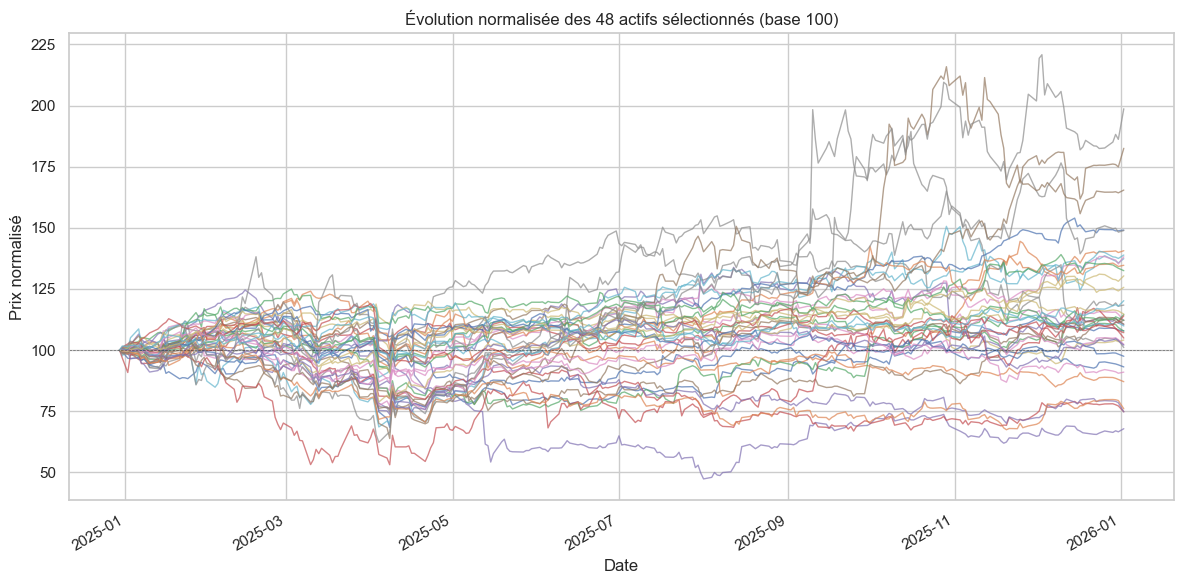

In [6]:
# Visualisation rapide : évolution normalisée des prix (base 100 au début)
prices_normalized = 100 * prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))
prices_normalized.plot(ax=ax, lw=1, alpha=0.7, legend=False)
ax.set_title(f"Évolution normalisée des {N_ASSETS} actifs sélectionnés (base 100)")
ax.set_ylabel("Prix normalisé")
ax.set_xlabel("Date")
ax.axhline(100, color="black", lw=0.5, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Calcul des rendements hebdomadaires

### 3.1 Choix méthodologiques


**(a) Rendements simples ou log-rendements ?**

Deux définitions :
$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}, \qquad r_t^{\log} = \ln\!\left(\frac{P_t}{P_{t-1}}\right)$$

Les log-rendements ont deux avantages :
- ils sont **additifs dans le temps** : $r_{t_0 \to t_2}^{\log} = r_{t_0 \to t_1}^{\log} + r_{t_1 \to t_2}^{\log}$ ;
- ils sont mieux approximés par une gaussienne (cohérent avec l'hypothèse de Markowitz).

En revanche, la formule du rendement de portefeuille $\mu_p = w^\top \mu$ est *exacte* avec les rendements simples mais *approximée* avec les log-rendements (cette approximation est très bonne pour de petites variations).

**Pour ce notebook**, j'ai choisit les **log-rendements**. L'écart est négligeable sur des rendements hebdomadaires de quelques %.

**(b) Resampling hebdomadaire**

On agrège les prix journaliers en prix **fin de semaine (vendredi)**, puis on calcule les rendements entre vendredis successifs.
On aurait aussi pu calculer les moyenne par semaine.

In [7]:
# Resampling : on prend le dernier prix observé chaque semaine (vendredi en général)
weekly_prices = prices.resample("W-FRI").last()

# Log-rendements hebdomadaires
weekly_log_returns = np.log(weekly_prices / weekly_prices.shift(1)).dropna()

print(f"Nombre de semaines : {len(weekly_log_returns)}")
print(f"Nombre d'actifs    : {weekly_log_returns.shape[1]}")
print(f"\nAperçu des 5 premières lignes :")
weekly_log_returns.head()

Nombre de semaines : 52
Nombre d'actifs    : 40

Aperçu des 5 premières lignes :


Ticker,AAPL,LLY,MA,MCD,META,MRK,MSFT,NFLX,LIN,NVDA,...,COST,CRM,CSCO,CVX,DIS,GOOGL,HD,INTC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-10,-0.0271,0.0227,-0.0311,-0.0432,0.0184,0.0011,-0.0104,-0.0505,0.0016,-0.0611,...,0.0220,-0.0463,-0.0020,0.0352,-0.0228,0.0013,0.0018,-0.0710,0.0242,-0.0123
2025-01-17,-0.0294,-0.0973,0.0389,-0.0048,-0.0050,-0.0135,0.0238,0.0241,0.0514,0.0132,...,0.0066,0.0209,0.0250,0.0530,-0.0151,0.0204,0.0488,0.1153,-0.0115,0.0528
2025-01-24,-0.0318,0.0790,0.0166,0.0159,0.0551,-0.0245,0.0344,0.1304,0.0074,0.0350,...,-0.0037,0.0283,0.0327,-0.0367,0.0469,0.0213,0.0124,-0.0312,0.0302,-0.0331
2025-01-31,0.0576,0.0322,0.0403,0.0113,0.0624,0.0337,-0.0675,-0.0008,0.0155,-0.1721,...,0.0419,0.0232,-0.0265,-0.0424,0.0080,0.0189,-0.0061,-0.0696,0.0353,-0.0170
2025-02-07,-0.0361,0.0796,0.0131,0.0192,0.0361,-0.1242,-0.0129,0.0373,0.0198,0.0782,...,0.0643,-0.0476,0.0272,0.0227,-0.0197,-0.0960,-0.0113,-0.0171,0.0300,0.0191


In [8]:
T, N = weekly_log_returns.shape
print(f"T (semaines) = {T}")
print(f"N (actifs)   = {N}")
print(f"Ratio T/N    = {T/N:.2f}")
if T > N:
    print(f"[OK] T > N : Sigma sera inversible (sauf colinéarités).")
else:
    print(f"[ATTENTION] T <= N : Sigma sera singulière. Réduire N_ASSETS ou utiliser un shrinkage.")

T (semaines) = 52
N (actifs)   = 40
Ratio T/N    = 1.30
[OK] T > N : Sigma sera inversible (sauf colinéarités).


In [9]:
# Statistiques descriptives
desc = weekly_log_returns.describe().T[["mean", "std", "min", "max"]]
desc.columns = ["Moyenne hebdo", "Vol hebdo", "Min hebdo", "Max hebdo"]
desc = desc.sort_values("Moyenne hebdo", ascending=False)
print("Top 10 par rendement moyen hebdomadaire :")
desc.head(10)

Top 10 par rendement moyen hebdomadaire :


,Moyenne hebdo,Vol hebdo,Min hebdo,Max hebdo
Ticker,,,,
INTC,0.0125,0.0827,-0.1395,0.2116
AMD,0.0111,0.0767,-0.1916,0.2662
GOOGL,0.0096,0.0443,-0.0960,0.0987
AVGO,0.0079,0.0677,-0.1450,0.2181
JNJ,0.0076,0.0242,-0.0661,0.0490
LLY,0.0064,0.0653,-0.1976,0.1477
JPM,0.0060,0.0392,-0.1379,0.1162
WFC,0.0060,0.0444,-0.1478,0.0969
CSCO,0.0054,0.0346,-0.1030,0.0930


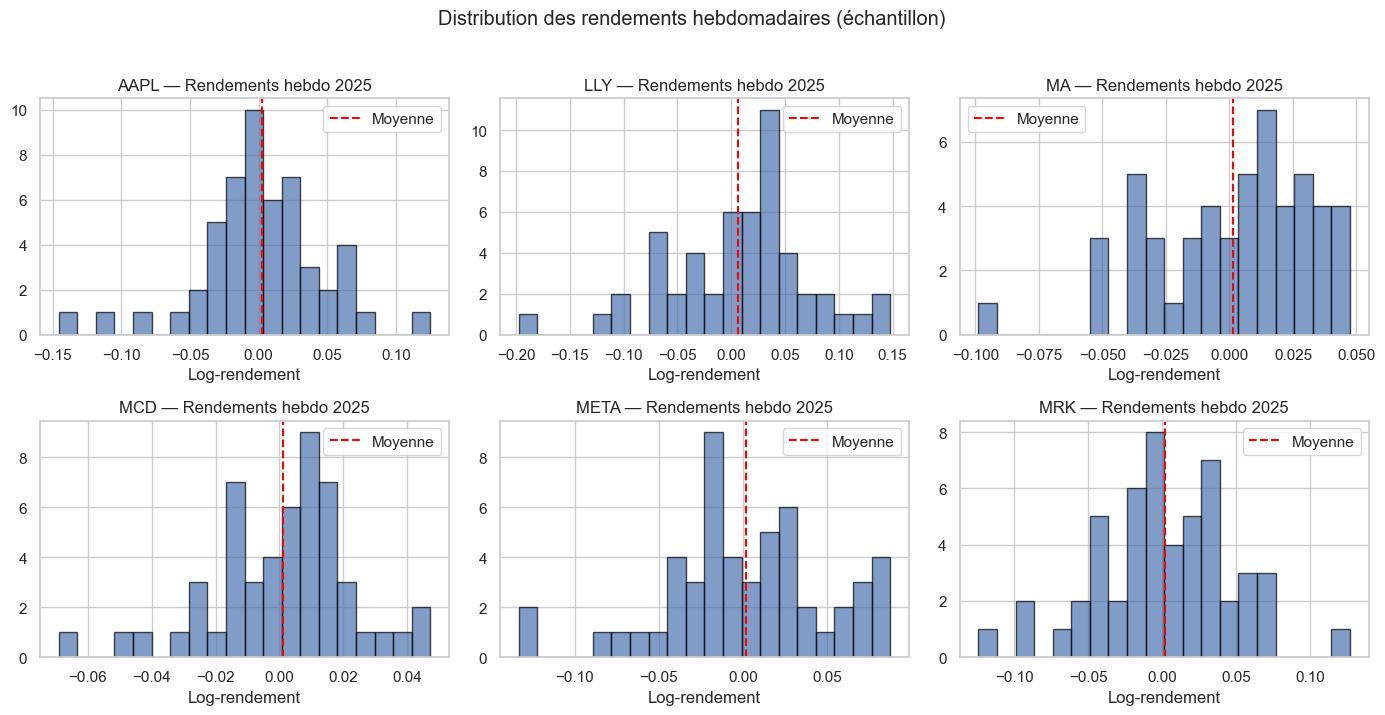

In [10]:
# Visualisation : distribution des rendements hebdo de quelques actifs représentatifs
sample = weekly_log_returns.columns[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, ticker in zip(axes.flat, sample):
    weekly_log_returns[ticker].hist(bins=20, ax=ax, edgecolor="black", alpha=0.7)
    ax.axvline(weekly_log_returns[ticker].mean(), color="red", ls="--", label="Moyenne")
    ax.set_title(f"{ticker} — Rendements hebdo 2025")
    ax.set_xlabel("Log-rendement")
    ax.legend()
plt.suptitle("Distribution des rendements hebdomadaires (échantillon)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Estimation de μ et Σ

### 4.1 Estimateurs empiriques

**Vecteur des rendements espérés** :
$$\hat\mu_i = \frac{1}{T}\sum_{t=1}^T r_{i,t}$$

**Matrice de covariance** :
$$\hat\Sigma_{ij} = \frac{1}{T-1}\sum_{t=1}^T (r_{i,t} - \hat\mu_i)(r_{j,t} - \hat\mu_j)$$

### 4.2 Annualisation

Pour des rendements **hebdomadaires** (52 semaines par an) :
$$\hat\mu_{\text{annuel}} = 52 \times \hat\mu_{\text{hebdo}}, \qquad \hat\Sigma_{\text{annuel}} = 52 \times \hat\Sigma_{\text{hebdo}}$$

(Pour la covariance, le facteur 52 vient de l'hypothèse d'indépendance des rendements hebdomadaires : la variance d'une somme de 52 variables i.i.d. est 52 fois la variance d'une seule.)

On travaillera **en annualisé** dans toute la suite, c'est la convention standard pour interpréter les résultats.

In [11]:
WEEKS_PER_YEAR = 52

# Estimation en hebdo
mu_w     = weekly_log_returns.mean().values             # vecteur N
Sigma_w  = weekly_log_returns.cov().values              # matrice N x N

# Annualisation
mu       = mu_w    * WEEKS_PER_YEAR                     # rendement espéré annualisé
Sigma    = Sigma_w * WEEKS_PER_YEAR                     # covariance annualisée

# Pour mémoire, on garde aussi r_f en annualisé
r_f      = RISK_FREE_W * WEEKS_PER_YEAR                 # ~4% annuel

tickers  = weekly_log_returns.columns.tolist()
N        = len(tickers)

print(f"mu    shape : {mu.shape}   (vecteur de longueur N={N})")
print(f"Sigma shape : {Sigma.shape}")
print(f"\nRendements annualisés (top 5) :")
print(pd.Series(mu, index=tickers).sort_values(ascending=False).head().to_string())

mu    shape : (40,)   (vecteur de longueur N=40)
Sigma shape : (40, 40)

Rendements annualisés (top 5) :
INTC    0.6499
AMD     0.5780
GOOGL   0.5006
AVGO    0.4110
JNJ     0.3934


In [12]:
# Diagnostic numérique de Sigma : conditionnement et inversibilité
eigenvalues = np.linalg.eigvalsh(Sigma)
cond_number = eigenvalues.max() / max(eigenvalues.min(), 1e-12)

print(f"Valeurs propres de Sigma :")
print(f"  min  = {eigenvalues.min():.6e}")
print(f"  max  = {eigenvalues.max():.6e}")
print(f"  conditionnement (max/min) = {cond_number:.2e}")
print()
if eigenvalues.min() < 1e-8:
    print("[ALERTE] Une valeur propre est quasi nulle : Sigma est mal conditionnée ou singulière.")
    print("         La solution analytique sera instable. Envisager un shrinkage ou réduire N.")
elif cond_number > 1e6:
    print("[ATTENTION] Conditionnement élevé : la solution analytique peut être bruitée.")
else:
    print("[OK] Sigma est bien conditionnée : on peut l'inverser sans souci numérique majeur.")

Valeurs propres de Sigma :
  min  = 1.860595e-04
  max  = 1.377042e+00
  conditionnement (max/min) = 7.40e+03

[OK] Sigma est bien conditionnée : on peut l'inverser sans souci numérique majeur.


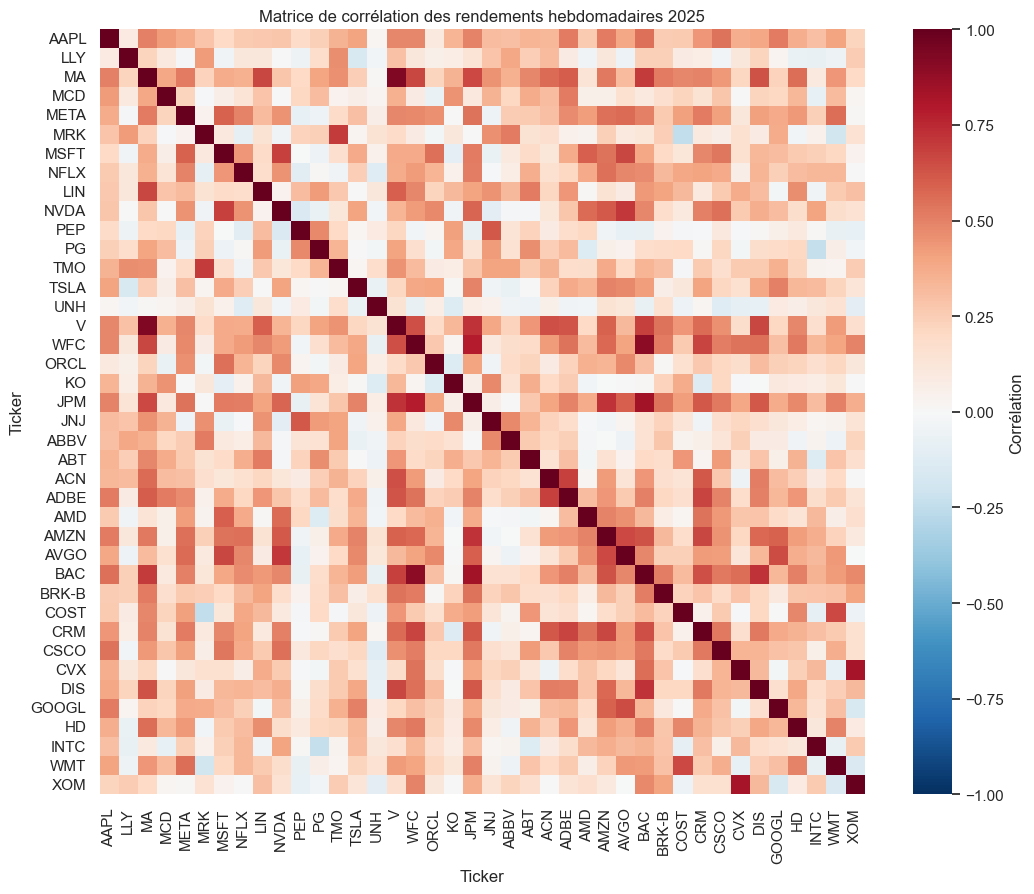

Corrélation moyenne (hors diagonale) : 0.248


In [13]:
# Matrice de corrélation (plus interprétable que la covariance)
corr = weekly_log_returns.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"label": "Corrélation"},
    xticklabels=True, yticklabels=True,
    ax=ax,
)
ax.set_title("Matrice de corrélation des rendements hebdomadaires 2025")
plt.tight_layout()
plt.show()

print(f"Corrélation moyenne (hors diagonale) : {(corr.values.sum() - N) / (N*(N-1)):.3f}")

La plupart des corrélations choisies sont positives, ce qui est attendu sur le S&P 500 (tous les actifs subissent le « facteur marché »). Cela limite un peu les gains de diversification. A creuser/diversifier dans l'echantillonage 

## 5. Méthode 1 — Optimisation par Lagrangien analytique

### 5.1 Rappel théorique

On résout la formulation suivante :
$$\min_w \; \frac{1}{2} w^\top \Sigma w \quad \text{s.c.} \quad w^\top \mu = \mu_{\text{cible}}, \quad w^\top \mathbf{1} = 1$$

Le Lagrangien :
$$\mathcal{L}(w, \lambda_1, \lambda_2) = \tfrac{1}{2} w^\top \Sigma w - \lambda_1 (w^\top \mu - \mu_{\text{cible}}) - \lambda_2 (w^\top \mathbf{1} - 1)$$

Condition du premier ordre : $\Sigma w = \lambda_1 \mu + \lambda_2 \mathbf{1}$, donc $w^* = \Sigma^{-1}(\lambda_1 \mu + \lambda_2 \mathbf{1})$.

En injectant dans les contraintes, on définit les scalaires :
$$A = \mathbf{1}^\top \Sigma^{-1} \mu, \quad B = \mu^\top \Sigma^{-1} \mu, \quad C = \mathbf{1}^\top \Sigma^{-1} \mathbf{1}, \quad D = BC - A^2$$

Et l'on obtient :
$$\boxed{\, w^* = \frac{1}{D}\!\left[(B - A\mu_{\text{cible}})\,\Sigma^{-1}\mathbf{1} + (C\mu_{\text{cible}} - A)\,\Sigma^{-1}\mu\right]}$$

Cas particulier : **portefeuille de variance minimale** (MVP), où l'on ne fixe pas de rendement cible :
$$w_{\text{MVP}} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^\top \Sigma^{-1}\mathbf{1}}$$

### 5.2 Limites de la méthode

⚠️ Cette approche admet les **ventes à découvert** ($w_i$ peut être négatif). Elle ne permet **pas** d'imposer une contrainte long-only ($w_i \geq 0$) — ce sera l'objet de la méthode 2.

C'est pourquoi on obtient parfois des poids extrêmes 


### NB: 
On aurait pu aussi faire le choix de:
1. Maximiser le rendement pour un risque cible :

$$
\begin{aligned}
\max_{w} \quad & w^\top \mu \\
\text{s.c.} \quad & w^\top \Sigma w \leq \sigma^2_{\text{cible}} \\
& w^\top \mathbf{1} = 1
\end{aligned}
$$

2. Maximiser l'utilité: 

$$
\max_{w} \quad w^\top \mu - \frac{\lambda}{2} w^\top \Sigma w \quad \text{s.c.} \quad w^\top \mathbf{1} = 1
$$

où $\lambda > 0$ est le **coefficient d'aversion au risque**. Plus $\lambda$ est grand, plus l'investisseur pénalise le risque. Cette forme ne nécessite pas de fixer une cible, on balaie $\lambda$ pour générer toute la frontière.

In [14]:
class MarkowitzLagrangian:
    """
    Résout le problème de Markowitz par les multiplicateurs de Lagrange,
    en forme fermée. Permet les ventes à découvert.

    Convention : tous les rendements et la covariance sont passés en annualisé.
    """

    def __init__(self, mu: np.ndarray, Sigma: np.ndarray):
        self.mu     = np.asarray(mu).flatten()
        self.Sigma  = np.asarray(Sigma)
        self.N      = len(self.mu)
        self.ones   = np.ones(self.N)

        # On calcule Sigma^{-1} une seule fois (utilisée partout)
        self.Sigma_inv = np.linalg.inv(self.Sigma)

        # Constantes A, B, C, D
        self.A = self.ones @ self.Sigma_inv @ self.mu
        self.B = self.mu   @ self.Sigma_inv @ self.mu
        self.C = self.ones @ self.Sigma_inv @ self.ones
        self.D = self.B * self.C - self.A ** 2

    # ---------- Portefeuille de variance minimale (MVP) ----------
    def mvp(self) -> np.ndarray:
        """Portefeuille de variance minimale (sans rendement cible)."""
        return (self.Sigma_inv @ self.ones) / self.C

    # ---------- Portefeuille efficient pour un rendement cible ----------
    def weights_for_target_return(self, mu_target: float) -> np.ndarray:
        """Poids minimisant la variance sous contrainte mu^T w = mu_target."""
        term1 = (self.B - self.A * mu_target) * (self.Sigma_inv @ self.ones)
        term2 = (self.C * mu_target - self.A) * (self.Sigma_inv @ self.mu)
        return (term1 + term2) / self.D

    # ---------- Portefeuille tangent (max Sharpe) ----------
    def tangency_portfolio(self, r_f: float) -> np.ndarray:
        """
        Portefeuille tangent : maximise (mu_p - r_f) / sigma_p.
        Formule fermée : w_T = Sigma^{-1} (mu - r_f * 1) / [1^T Sigma^{-1} (mu - r_f * 1)].
        """
        excess = self.mu - r_f * self.ones
        unnorm = self.Sigma_inv @ excess
        return unnorm / (self.ones @ unnorm)

    # ---------- Frontière efficiente analytique ----------
    def efficient_frontier(self, n_points: int = 100):
        """
        Renvoie n_points portefeuilles sur la frontière, leur rendement et leur risque.
        On balaie mu_target entre min(mu) et max(mu).
        """
        mu_targets = np.linspace(self.mu.min(), self.mu.max(), n_points)
        weights_list  = np.zeros((n_points, self.N))
        sigmas        = np.zeros(n_points)
        for i, mu_t in enumerate(mu_targets):
            w = self.weights_for_target_return(mu_t)
            weights_list[i] = w
            sigmas[i]       = np.sqrt(w @ self.Sigma @ w)
        return mu_targets, sigmas, weights_list

    # ---------- Utilitaires ----------
    def portfolio_stats(self, w: np.ndarray, r_f: float = 0.0):
        """Renvoie (rendement, volatilité, Sharpe) annualisés d'un portefeuille."""
        mu_p    = float(w @ self.mu)
        sigma_p = float(np.sqrt(w @ self.Sigma @ w))
        sharpe  = (mu_p - r_f) / sigma_p if sigma_p > 0 else np.nan
        return mu_p, sigma_p, sharpe


# Instanciation
mkw = MarkowitzLagrangian(mu, Sigma)
print(f"Constantes : A={mkw.A:.4f}, B={mkw.B:.4f}, C={mkw.C:.4f}, D={mkw.D:.4f}")

Constantes : A=12.3585, B=92.2291, C=996.1056, D=91717.1788


### 5.3 Portefeuille de variance minimale (MVP)

In [15]:
w_mvp = mkw.mvp()
mu_mvp, sigma_mvp, sharpe_mvp = mkw.portfolio_stats(w_mvp, r_f)

print(f"--- Portefeuille MVP (Lagrangien) ---")
print(f"  Rendement annualisé  : {mu_mvp*100:7.2f} %")
print(f"  Volatilité annualisée: {sigma_mvp*100:7.2f} %")
print(f"  Ratio de Sharpe      : {sharpe_mvp:7.3f}")
print(f"  Somme des poids      : {w_mvp.sum():.4f}  (doit être 1)")
print(f"  Poids min / max      : {w_mvp.min():.3f} / {w_mvp.max():.3f}")
print(f"  Nb poids négatifs    : {(w_mvp < 0).sum()}  ← ventes à découvert")

--- Portefeuille MVP (Lagrangien) ---
  Rendement annualisé  :    1.24 %
  Volatilité annualisée:    3.17 %
  Ratio de Sharpe      :  -0.871
  Somme des poids      : 1.0000  (doit être 1)
  Poids min / max      : -0.354 / 0.432
  Nb poids négatifs    : 20  ← ventes à découvert


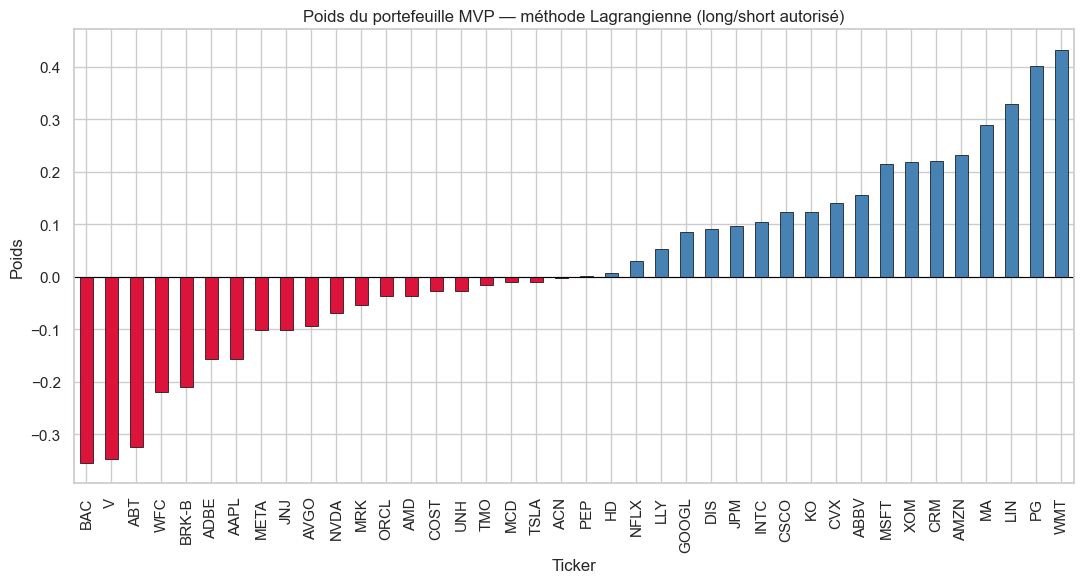

In [16]:
# Visualisation des poids du MVP
w_mvp_series = pd.Series(w_mvp, index=tickers).sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["crimson" if x < 0 else "steelblue" for x in w_mvp_series]
w_mvp_series.plot(kind="bar", color=colors, ax=ax, edgecolor="black", lw=0.5)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Poids du portefeuille MVP — méthode Lagrangienne (long/short autorisé)")
ax.set_ylabel("Poids")
ax.set_xlabel("Ticker")
plt.tight_layout()
plt.show()

### 5.4 Portefeuille tangent (Sharpe maximum)

In [17]:
w_tan = mkw.tangency_portfolio(r_f)
mu_tan, sigma_tan, sharpe_tan = mkw.portfolio_stats(w_tan, r_f)

print(f"--- Portefeuille tangent (Lagrangien, long/short autorisé) ---")
print(f"  Rendement annualisé  : {mu_tan*100:7.2f} %")
print(f"  Volatilité annualisée: {sigma_tan*100:7.2f} %")
print(f"  Ratio de Sharpe      : {sharpe_tan:7.3f}")
print(f"  Somme des poids      : {w_tan.sum():.4f}")
print(f"  Poids min / max      : {w_tan.min():.3f} / {w_tan.max():.3f}")
print(f"  Nb poids négatifs    : {(w_tan < 0).sum()}")

print("\nTop 5 positions longues :")
print(pd.Series(w_tan, index=tickers).sort_values(ascending=False).head().to_string())
print("\nTop 5 positions courtes :")
print(pd.Series(w_tan, index=tickers).sort_values().head().to_string())

--- Portefeuille tangent (Lagrangien, long/short autorisé) ---
  Rendement annualisé  : -333.75 %
  Volatilité annualisée:   35.05 %
  Ratio de Sharpe      :  -9.635
  Somme des poids      : 1.0000
  Poids min / max      : -6.548 / 7.225
  Nb poids négatifs    : 15

Top 5 positions longues :
MA     7.2252
CVX    3.5001
PEP    2.0496
DIS    1.7588
NFLX   1.5003

Top 5 positions courtes :
V      -6.5476
BAC    -4.8392
JNJ    -3.7885
ABT    -2.3413
AMZN   -1.6436


**Lecture** : on observe immédiatement le problème classique de Markowitz sans contrainte — les poids sont **très concentrés** et peuvent atteindre des valeurs extrêmes (positives et négatives). C'est ce que Michaud (1989) appelle l'« error-maximizing machine » : le modèle exploite les moindres différences statistiques entre actifs, en grande partie du bruit d'estimation.

C'est exactement ce que la méthode 2 (contraintes long-only) va corriger.

### 5.5 Frontière efficiente analytique

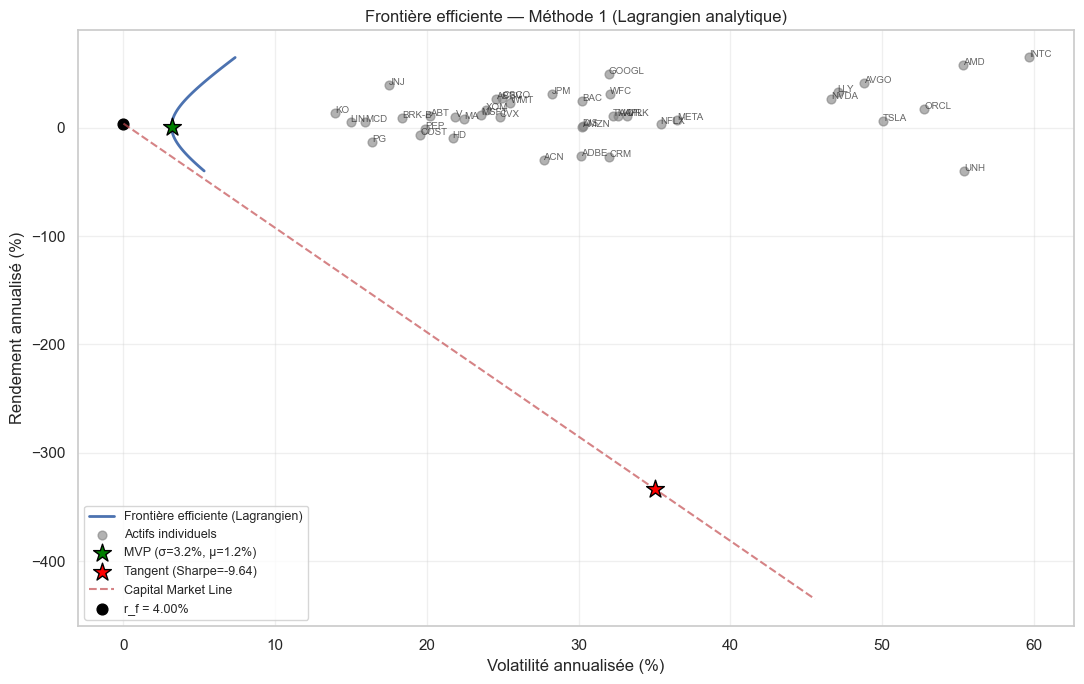

In [18]:
mu_targets, sigmas_eff, _ = mkw.efficient_frontier(n_points=100)

# Stats individuelles des actifs pour les afficher en nuage de points
individual_sigmas = np.sqrt(np.diag(Sigma))
individual_mus    = mu

fig, ax = plt.subplots(figsize=(11, 7))

# Frontière efficiente
ax.plot(sigmas_eff * 100, mu_targets * 100, "b-", lw=2, label="Frontière efficiente (Lagrangien)")

# Actifs individuels
ax.scatter(individual_sigmas * 100, individual_mus * 100, c="gray", alpha=0.6, s=40, label="Actifs individuels")
for i, t in enumerate(tickers):
    ax.annotate(t, (individual_sigmas[i]*100, individual_mus[i]*100), fontsize=7, alpha=0.7)

# Points clés : MVP et tangent
ax.scatter(sigma_mvp*100, mu_mvp*100, c="green", s=180, marker="*",
           label=f"MVP (σ={sigma_mvp*100:.1f}%, μ={mu_mvp*100:.1f}%)", zorder=5, edgecolor="black")
ax.scatter(sigma_tan*100, mu_tan*100, c="red", s=180, marker="*",
           label=f"Tangent (Sharpe={sharpe_tan:.2f})", zorder=5, edgecolor="black")

# Capital Market Line (passe par r_f et le portefeuille tangent)
cml_x = np.array([0, sigma_tan*100*1.3])
cml_y = r_f*100 + sharpe_tan * cml_x
ax.plot(cml_x, cml_y, "r--", lw=1.5, alpha=0.7, label="Capital Market Line")
ax.scatter([0], [r_f*100], c="black", s=60, label=f"r_f = {r_f*100:.2f}%")

ax.set_xlabel("Volatilité annualisée (%)")
ax.set_ylabel("Rendement annualisé (%)")
ax.set_title("Frontière efficiente — Méthode 1 (Lagrangien analytique)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Méthode 2 — Programmation Quadratique (QP) via CVXPY

### 6.1 Pourquoi cette méthode

Le Lagrangien analytique a deux limites :

1. **Il ne gère que les contraintes d'égalité** ($w^\top\mathbf{1}=1$, $w^\top\mu=\mu_{\text{cible}}$). Pour imposer une **contrainte long-only** ($w_i \geq 0$, qui est une *inégalité*), les conditions KKT (Karush-Kuhn-Tucker) introduisent des multiplicateurs supplémentaires et la solution n'a plus de forme fermée.
2. **Il exige $\Sigma$ inversible**.

La **programmation quadratique** résout exactement le problème :
$$\min_w \; \frac{1}{2} w^\top \Sigma w \quad \text{s.c.} \quad A_{\text{eq}} w = b_{\text{eq}}, \quad A_{\text{ineq}} w \leq b_{\text{ineq}}$$

C'est un cas particulier d'**optimisation convexe**, résolu par des **méthodes de points intérieurs** (algorithme primal-dual). Aucun gradient n'est descendu : le solveur résout directement les conditions KKT par itérations de Newton sur un système barrier.

`CVXPY` est un *modeleur* d'optimisation convexe : on écrit le problème en notation mathématique, il appelle un solveur sous le capot (OSQP, ECOS, SCS...).

### 6.2 Mise en œuvre

On va traiter **trois problèmes** :
- **MVP long-only** : minimum de variance avec $w_i \geq 0$.
- **Portefeuille tangent long-only** (max Sharpe avec contrainte de positivité).
- **Frontière efficiente long-only** : balayage du rendement cible.

In [ ]:
def solve_mvp_qp(mu, Sigma, long_only=True, w_max=1.0):
    """
    MVP par programmation quadratique.
        min  (1/2) w^T Sigma w
        s.c. sum(w) = 1
             0 <= w_i <= w_max  (si long_only)
    """
    N = len(mu)
    w = cp.Variable(N)
    objective   = cp.Minimize(0.5 * cp.quad_form(w, cp.psd_wrap(Sigma)))
    constraints = [cp.sum(w) == 1]
    if long_only:
        constraints += [w >= 0, w <= w_max]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return w.value, prob.status


def solve_target_return_qp(mu, Sigma, mu_target, long_only=True, w_max=1.0):
    """
    Portefeuille efficient pour un rendement cible donné, via QP.
        min  (1/2) w^T Sigma w
        s.c. mu^T w = mu_target
             sum(w) = 1
             0 <= w_i <= w_max  (si long_only)
    """
    N = len(mu)
    w = cp.Variable(N)
    objective   = cp.Minimize(0.5 * cp.quad_form(w, cp.psd_wrap(Sigma)))
    constraints = [
        cp.sum(w) == 1,
        mu @ w == mu_target,
    ]
    if long_only:
        constraints += [w >= 0, w <= w_max]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return w.value, prob.status


def solve_max_sharpe_qp(mu, Sigma, r_f, long_only=True, w_max=1.0):
    """
    Maximisation du ratio de Sharpe via la reformulation convexe classique.

    Le problème direct max (mu - r_f*1)^T w / sqrt(w^T Sigma w) n'est pas convexe.
    Astuce : on cherche y = w / kappa (avec kappa > 0) et on résout
        min  y^T Sigma y
        s.c. (mu - r_f * 1)^T y = 1
             y >= 0  (si long_only)
    Le ratio est ensuite reconstruit via w = y / sum(y).
    """
    N = len(mu)
    y = cp.Variable(N)
    excess = mu - r_f * np.ones(N)
    objective = cp.Minimize(cp.quad_form(y, cp.psd_wrap(Sigma)))
    constraints = [excess @ y == 1]
    if long_only:
        constraints += [y >= 0]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    if y.value is None:
        return None, prob.status
    w = y.value / np.sum(y.value)
    return w, prob.status

### 6.3 MVP long-only

In [20]:
w_mvp_lo, status = solve_mvp_qp(mu, Sigma, long_only=True)
mu_mvp_lo, sigma_mvp_lo, sharpe_mvp_lo = mkw.portfolio_stats(w_mvp_lo, r_f)

print(f"--- MVP long-only (QP / CVXPY) ---")
print(f"  Statut solveur       : {status}")
print(f"  Rendement annualisé  : {mu_mvp_lo*100:7.2f} %")
print(f"  Volatilité annualisée: {sigma_mvp_lo*100:7.2f} %")
print(f"  Ratio de Sharpe      : {sharpe_mvp_lo:7.3f}")
print(f"  Somme des poids      : {w_mvp_lo.sum():.4f}")
print(f"  Poids min / max      : {w_mvp_lo.min():.4f} / {w_mvp_lo.max():.4f}")
print(f"  Nb poids significatifs (>1%) : {(w_mvp_lo > 0.01).sum()}/{N}")

--- MVP long-only (QP / CVXPY) ---
  Statut solveur       : optimal
  Rendement annualisé  :    5.98 %
  Volatilité annualisée:    8.91 %
  Ratio de Sharpe      :   0.222
  Somme des poids      : 1.0000
  Poids min / max      : -0.0000 / 0.2409
  Nb poids significatifs (>1%) : 11/40


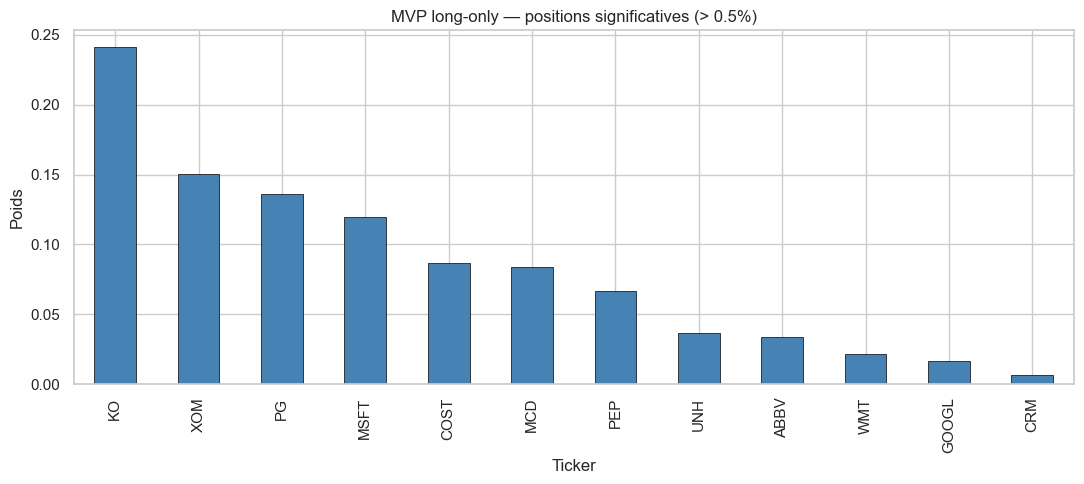

In [21]:
# Visualisation : top positions du MVP long-only
w_mvp_lo_series = pd.Series(w_mvp_lo, index=tickers).sort_values(ascending=False)
significant = w_mvp_lo_series[w_mvp_lo_series > 0.005]   # ne garde que les positions > 0.5%

fig, ax = plt.subplots(figsize=(11, 5))
significant.plot(kind="bar", color="steelblue", ax=ax, edgecolor="black", lw=0.5)
ax.set_title(f"MVP long-only — positions significatives (> 0.5%)")
ax.set_ylabel("Poids")
ax.set_xlabel("Ticker")
plt.tight_layout()
plt.show()

### 6.4 Portefeuille tangent long-only (max Sharpe)

In [22]:
w_tan_lo, status = solve_max_sharpe_qp(mu, Sigma, r_f, long_only=True)
mu_tan_lo, sigma_tan_lo, sharpe_tan_lo = mkw.portfolio_stats(w_tan_lo, r_f)

print(f"--- Portefeuille tangent long-only (QP / CVXPY) ---")
print(f"  Statut solveur       : {status}")
print(f"  Rendement annualisé  : {mu_tan_lo*100:7.2f} %")
print(f"  Volatilité annualisée: {sigma_tan_lo*100:7.2f} %")
print(f"  Ratio de Sharpe      : {sharpe_tan_lo:7.3f}")
print(f"  Somme des poids      : {w_tan_lo.sum():.4f}")
print(f"  Poids max            : {w_tan_lo.max():.4f}")
print(f"  Nb poids significatifs (>1%) : {(w_tan_lo > 0.01).sum()}/{N}")

print("\nTop 10 positions :")
print(pd.Series(w_tan_lo, index=tickers).sort_values(ascending=False).head(10).to_string())

--- Portefeuille tangent long-only (QP / CVXPY) ---
  Statut solveur       : optimal
  Rendement annualisé  :   41.04 %
  Volatilité annualisée:   14.26 %
  Ratio de Sharpe      :   2.598
  Somme des poids      : 1.0000
  Poids max            : 0.5775
  Nb poids significatifs (>1%) : 7/40

Top 10 positions :
JNJ     0.5775
GOOGL   0.1577
WMT     0.0929
INTC    0.0612
AMD     0.0552
XOM     0.0411
LLY     0.0143
CRM     0.0000
TSLA    0.0000
ACN     0.0000


**Observation typique** : le portefeuille tangent long-only se concentre souvent sur **quelques actifs** seulement (3-7). C'est lié à la concentration de la frontière efficiente lorsque les ventes à découvert sont interdites — les actifs « dominés » se voient attribuer un poids nul. Pour éviter cette concentration excessive, on ajoute en pratique un **plafond par actif** (ex. $w_i \leq 0.10$), facile à imposer dans le QP.

### 6.5 Frontière efficiente long-only

In [23]:
# Détermination des bornes : mu_target faisable entre le MVP et le rendement max possible
# Le rendement max long-only est obtenu en mettant 100% sur l'actif au plus haut rendement
mu_min_feasible = mu_mvp_lo                    # rendement du MVP
mu_max_feasible = mu.max() * 0.999             # un poil sous le max pour éviter coin

n_grid = 40
mu_grid = np.linspace(mu_min_feasible, mu_max_feasible, n_grid)

frontier_sigmas_lo = []
frontier_mus_lo    = []
frontier_weights_lo = []

for mu_t in mu_grid:
    w_opt, status = solve_target_return_qp(mu, Sigma, mu_t, long_only=True)
    if w_opt is None or status not in ("optimal", "optimal_inaccurate"):
        continue
    mu_p_, sigma_p_, _ = mkw.portfolio_stats(w_opt, r_f)
    frontier_mus_lo.append(mu_p_)
    frontier_sigmas_lo.append(sigma_p_)
    frontier_weights_lo.append(w_opt)

frontier_mus_lo    = np.array(frontier_mus_lo)
frontier_sigmas_lo = np.array(frontier_sigmas_lo)

print(f"Nombre de portefeuilles sur la frontière : {len(frontier_mus_lo)}")

Nombre de portefeuilles sur la frontière : 40


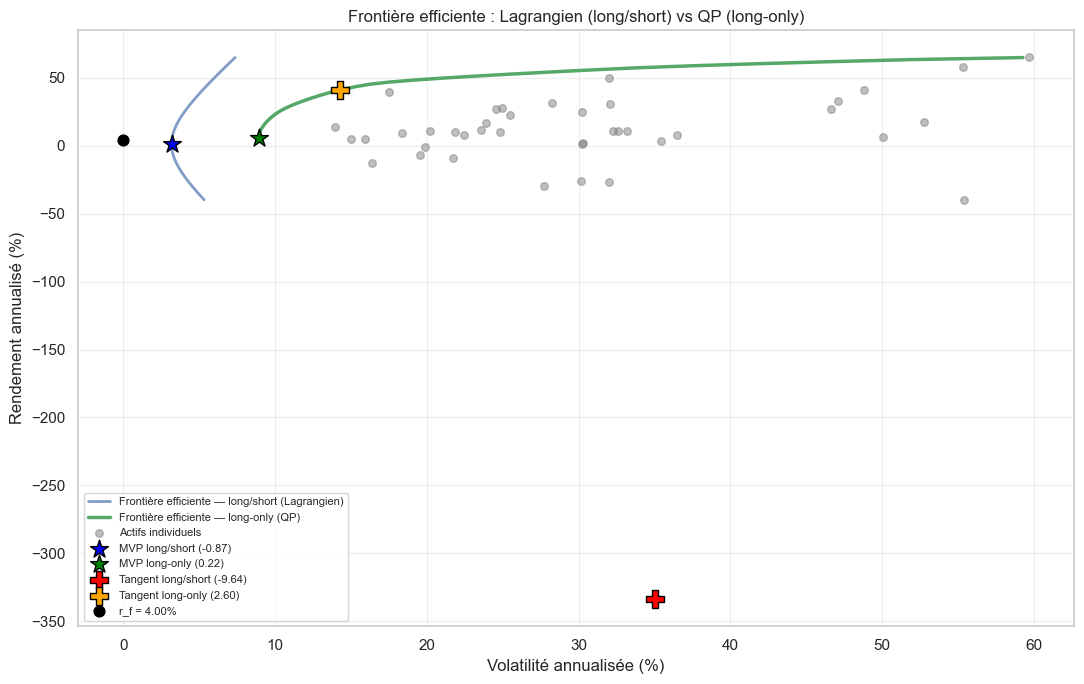

In [24]:
# Comparaison visuelle : frontière long/short (Lagrangien) vs frontière long-only (QP)
fig, ax = plt.subplots(figsize=(11, 7))

# Frontière analytique (Lagrangien, long/short autorisé)
ax.plot(sigmas_eff * 100, mu_targets * 100, "b-", lw=2, alpha=0.7,
        label="Frontière efficiente — long/short (Lagrangien)")

# Frontière long-only (QP)
ax.plot(frontier_sigmas_lo * 100, frontier_mus_lo * 100, "g-", lw=2.5,
        label="Frontière efficiente — long-only (QP)")

# Actifs individuels
ax.scatter(individual_sigmas * 100, individual_mus * 100, c="gray", alpha=0.5, s=30, label="Actifs individuels")

# Points clés
ax.scatter(sigma_mvp*100, mu_mvp*100, c="blue", s=180, marker="*",
           label=f"MVP long/short ({sharpe_mvp:.2f})", zorder=5, edgecolor="black")
ax.scatter(sigma_mvp_lo*100, mu_mvp_lo*100, c="green", s=180, marker="*",
           label=f"MVP long-only ({sharpe_mvp_lo:.2f})", zorder=5, edgecolor="black")
ax.scatter(sigma_tan*100, mu_tan*100, c="red", s=180, marker="P",
           label=f"Tangent long/short ({sharpe_tan:.2f})", zorder=5, edgecolor="black")
ax.scatter(sigma_tan_lo*100, mu_tan_lo*100, c="orange", s=180, marker="P",
           label=f"Tangent long-only ({sharpe_tan_lo:.2f})", zorder=5, edgecolor="black")

ax.scatter([0], [r_f*100], c="black", s=60, label=f"r_f = {r_f*100:.2f}%")

ax.set_xlabel("Volatilité annualisée (%)")
ax.set_ylabel("Rendement annualisé (%)")
ax.set_title("Frontière efficiente : Lagrangien (long/short) vs QP (long-only)")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Comparaison synthétique des deux méthodes

### 7.1 Tableau récapitulatif

In [25]:
def herfindahl(w):
    """Indice de Herfindahl : mesure la concentration du portefeuille.
       1/N = parfaitement diversifié ; 1 = tout sur un seul actif."""
    return float(np.sum(np.asarray(w) ** 2))

comparison = pd.DataFrame({
    "Méthode 1 — MVP (Lagr.)" : [mu_mvp*100, sigma_mvp*100, sharpe_mvp,
                                  (w_mvp < 0).sum(), herfindahl(w_mvp)],
    "Méthode 2 — MVP (QP LO)" : [mu_mvp_lo*100, sigma_mvp_lo*100, sharpe_mvp_lo,
                                  (w_mvp_lo < -1e-6).sum(), herfindahl(w_mvp_lo)],
    "Méthode 1 — Tangent (Lagr.)": [mu_tan*100, sigma_tan*100, sharpe_tan,
                                     (w_tan < 0).sum(), herfindahl(w_tan)],
    "Méthode 2 — Tangent (QP LO)": [mu_tan_lo*100, sigma_tan_lo*100, sharpe_tan_lo,
                                     (w_tan_lo < -1e-6).sum(), herfindahl(w_tan_lo)],
}, index=["Rendement (%)", "Volatilité (%)", "Sharpe", "Nb shorts", "Herfindahl"]).T

comparison.round(3)

,Rendement (%),Volatilité (%),Sharpe,Nb shorts,Herfindahl
Méthode 1 — MVP (Lagr.),1.2410,3.1680,-0.8710,20.0000,1.3820
Méthode 2 — MVP (QP LO),5.9770,8.9070,0.2220,0.0000,0.1360
Méthode 1 — Tangent (Lagr.),-333.7540,35.0550,-9.6350,15.0000,177.9570
Méthode 2 — Tangent (QP LO),41.0400,14.2560,2.5980,0.0000,0.3760


## 8. Conclusion et prochaines étapes

### Ce qui a été fait

1.  Récupération des prix S&P 500 via `yfinance` sur 2025.
2.  Calcul des **log-rendements hebdomadaires**.
3.  Estimation de $\hat\mu$ et $\hat\Sigma$ annualisés, avec diagnostic du conditionnement.
4.  Résolution **Méthode 1** : Lagrangien analytique → MVP, portefeuille tangent, frontière efficiente complète.
5.  Résolution **Méthode 2** : Programmation Quadratique (CVXPY) → MVP long-only, tangent long-only, frontière long-only.
6.  Comparaison et validation croisée .


### Limites:
- **Pas de coûts de transaction**, pas de plafonds par actif, pas de contraintes sectorielles.
- **Pas de validation hors échantillon** (backtest).


### A ameliorer/modifier/tester sur ce notebook

- Essayer d'autres méthodes d'optimisation
- Choisir rendements au lieu de log-rendements 
- Travailler avec les autres formulations (minimiser le risque, ...)
- Augmenter la frequence T (toute l'année, semestre, trimestres, ...) ou le nombre d'actifs N

### Prochaines étapes / Suggestions 

- **Backtesting hebdomadaire sur 2025** : à chaque vendredi, ré-estimer $\hat\mu, \hat\Sigma$ sur la fenêtre glissante précédente, recalculer le portefeuille optimal, et mesurer la performance la semaine suivante.
- **Méthodologies JP Morgan** : moyennes mobiles avec fenêtre glissante, pondération exponentielle (EWMA) sur les rendements.
- **Métriques d'évaluation** : tracking error (par rapport à un benchmark equal-weight ou SPY), max drawdown, Sortino, turnover.
- **Élargissement de l'univers** : ajouter des ETF obligataires, sectoriels, internationaux pour vraie diversification trans-classes.
- **Brique ML** : prédire $\hat\mu$ par un modèle (Ridge sur factor exposures, ou un boosting léger), tout en gardant le squelette Markowitz.

Autres: plateforme streamlit ou l'on choisit les contraintes, methodes, parametres, perimètres ?
